### OKO ALEXANDER KENECHUKWU
### NICK ADAMS


In [1]:
# Files
import os
import io

from google.colab import files
from google.colab import drive
from google.colab import data_table
data_table.enable_dataframe_formatter()
#data_table.disable_dataframe_formatter()

import pandas as pd
import numpy as np


# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Linear Regression and anova
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.stats.anova import anova_lm

# Probability Distribution
from scipy.stats import norm, t, chi2, f

# Assumptions
from statsmodels.stats.stattools import durbin_watson
from statsmodels.sandbox.stats.runs import runstest_1samp
from scipy.stats import levene
from scipy.stats import shapiro
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan

#  Functions

In [2]:
#Forward Selection using AIC or BIC

def forward_selection_ic(df, response, predictors):
    remaining = set(predictors)
    selected = []
    current_score = float('inf')

    while remaining:
        scores = []

        for candidate in remaining:
            formula = f"{response} ~ {' + '.join(selected + [candidate])}"
            model = smf.ols(formula, data=df).fit()
            scores.append((model.aic, candidate))

        scores.sort()
        best_new_score, best_candidate = scores[0]

        if best_new_score < current_score:
            remaining.remove(best_candidate)
            selected.append(best_candidate)
            current_score = best_new_score
        else:
            break

    final_formula = f"{response} ~ {' + '.join(selected)}"
    final_model = smf.ols(final_formula, data=df).fit()

    return final_model, selected

In [3]:
#Backward Selection using AIC or BIC

def backward_elimination_ic(df, response, predictors, criterion='aic'):
    selected = predictors.copy()

    while True:
        formula = f"{response} ~ {' + '.join(selected)}"
        model = smf.ols(formula, data=df).fit()

        scores = []

        for candidate in selected:
            trial_vars = [v for v in selected if v != candidate]
            formula_trial = f"{response} ~ {' + '.join(trial_vars)}"
            trial_model = smf.ols(formula_trial, data=df).fit()

            score = trial_model.aic if criterion == 'aic' else trial_model.bic
            scores.append((score, candidate, trial_vars))

        scores.sort()
        best_new_score, worst_candidate, best_vars = scores[0]
        current_score = model.aic if criterion == 'aic' else model.bic

        if best_new_score < current_score:
            selected = best_vars
        else:
            break

    final_formula = f"{response} ~ {' + '.join(selected)}"
    final_model = smf.ols(final_formula, data=df).fit()

    return final_model, selected

In [4]:
## C_p
def get_mallows_cp(full_model, reduced_model):
    """
    full_model: The statsmodels OLS object with ALL predictors
    reduced_model: The statsmodels OLS object you are currently testing
    """
    n = full_model.nobs
    mse_full = full_model.mse_resid
    sse_reduced = reduced_model.ssr
    p_reduced = len(reduced_model.params)

    cp = (sse_reduced / mse_full) - n + (2 * p_reduced)
    return cp


In [5]:
# Press
import numpy as np

def press_p(model):

    # Get influence measures (including leverage/hat matrix)
    influence = model.get_influence()
    leverage = influence.hat_matrix_diag

    # Calculate PRESS residuals: e_i / (1 - h_ii)
    press_residuals = model.resid / (1 - leverage)

    # Square and sum
    press = np.sum(press_residuals**2)
    return press


In [6]:
drive.mount('/content/drive')
os.chdir('/content/drive/MyDrive/MATHPROJECT')


Mounted at /content/drive


Calling Raw Df

In [7]:
income_df= pd.read_csv('income_df.csv')

# Data Cleaning

In [8]:
# Drop empty columns
income_df = income_df.dropna(axis=1, how="all")

# Keep only relevant columns
income_df = income_df[["PWGTP", "SEX", "RAC1P", "SCHL", "PINCP", "AGEP", "WKHP"]]

# Convert to numeric
for col in income_df.columns:
    income_df[col] = pd.to_numeric(income_df[col], errors="coerce")

# Drop missing values
income_df = income_df.dropna()

# Remove invalid values
income_df = income_df[income_df["SEX"].isin([1, 2])]
income_df = income_df[(income_df["AGEP"] >= 0) & (income_df["AGEP"] <= 100)]
income_df = income_df[(income_df["WKHP"] >= 0) & (income_df["WKHP"] <= 99)]
income_df = income_df[income_df["PWGTP"] > 0]

# Optional: keep only positive income
income_df = income_df[income_df["PINCP"] > 0]

income_df.to_csv("cleaned_df.csv", index=False)

print(income_df.info())
print(income_df.describe())

<class 'pandas.core.frame.DataFrame'>
Index: 2556439 entries, 0 to 3422887
Data columns (total 7 columns):
 #   Column  Dtype
---  ------  -----
 0   PWGTP   int64
 1   SEX     int64
 2   RAC1P   int64
 3   SCHL    int64
 4   PINCP   int64
 5   AGEP    int64
 6   WKHP    int64
dtypes: int64(7)
memory usage: 156.0 MB
None
              PWGTP           SEX         RAC1P          SCHL         PINCP  \
count  2.556439e+06  2.556439e+06  2.556439e+06  2.556439e+06  2.556439e+06   
mean   9.590221e+01  1.504699e+00  2.534932e+00  1.837519e+01  6.227684e+04   
std    8.787224e+01  4.999780e-01  2.818002e+00  3.679058e+00  8.265522e+04   
min    1.000000e+00  1.000000e+00  1.000000e+00  1.000000e+00  1.000000e+00   
25%    4.700000e+01  1.000000e+00  1.000000e+00  1.600000e+01  1.800000e+04   
50%    7.100000e+01  2.000000e+00  1.000000e+00  1.900000e+01  4.000000e+04   
75%    1.130000e+02  2.000000e+00  2.000000e+00  2.100000e+01  7.500000e+04   
max    2.300000e+03  2.000000e+00  9.000000e+

In [9]:
# decode categorical variables

# SEX
income_df["SEX"] = income_df["SEX"].map({1: "Male", 2: "Female"}).astype("category")

# RAC1P
race_map = {
    1: "White",
    2: "Black",
    3: "American Indian",
    4: "Alaska Native",
    5: "AIAN tribes",
    6: "Asian",
    7: "Pacific Islander",
    8: "Other",
    9: "Two or more"
}
income_df["RAC1P"] = income_df["RAC1P"].map(race_map).astype("category")

# SCHL
schl_map = {
    7: "Grade 4",
    13: "Grade 10",
    16: "High School",
    20: "Associate",
    21: "Bachelor",
    22: "Master",
    23: "Professional",
    24: "Doctorate"
}
income_df["SCHL"] = income_df["SCHL"].map(schl_map).astype("category")

income_df = income_df.dropna(subset=["SCHL", "RAC1P", "SEX"])


In [10]:
# Optional: keep only positive income
income_df = income_df[income_df["PINCP"] > 0]

income_df.to_csv("cleaned_df.csv", index=False)

print(income_df.info())
print(income_df.describe())

<class 'pandas.core.frame.DataFrame'>
Index: 1749263 entries, 0 to 3422886
Data columns (total 7 columns):
 #   Column  Dtype   
---  ------  -----   
 0   PWGTP   int64   
 1   SEX     category
 2   RAC1P   category
 3   SCHL    category
 4   PINCP   int64   
 5   AGEP    int64   
 6   WKHP    int64   
dtypes: category(3), int64(4)
memory usage: 71.7 MB
None
              PWGTP         PINCP          AGEP          WKHP
count  1.749263e+06  1.749263e+06  1.749263e+06  1.749263e+06
mean   9.517343e+01  7.203247e+04  5.189076e+01  2.706046e+01
std    8.598668e+01  9.169544e+04  1.905203e+01  2.040307e+01
min    1.000000e+00  1.000000e+00  1.500000e+01  0.000000e+00
25%    4.800000e+01  2.210000e+04  3.600000e+01  0.000000e+00
50%    7.100000e+01  4.800000e+04  5.300000e+01  4.000000e+01
75%    1.120000e+02  8.700000e+04  6.700000e+01  4.000000e+01
max    2.300000e+03  1.945000e+06  9.600000e+01  9.900000e+01


# Example simplified race mapping for RAC1P
race_map = {
    1: "White alone",
    2: "Black alone",
    3: "American Indian alone",
    4: "Alaska Native alone",
    5: "American Indian and Alaska Native tribes specified",
    6: "Asian alone",
    7: "Native Hawaiian and Other Pacific Islander alone",
    8: "Some other race alone",
    9: "Two or more races"
}

# Example education mapping for SCHL
schl_map = {
    1: "No schooling completed",
    2: "Nursery school",
    3: "Kindergarten",
    4: "Grade 1",
    5: "Grade 2",
    6: "Grade 3",
    7: "Grade 4",
    8: "Grade 5",
    9: "Grade 6",
    10: "Grade 7",
    11: "Grade 8",
    12: "Grade 9",
    13: "Grade 10",
    14: "Grade 11",
    15: "12th grade - no diploma",
    16: "Regular high school diploma",
    17: "GED or alternative credential",
    18: "Some college, less than 1 year",
    19: "Some college, 1 or more years, no degree",
    20: "Associate's degree",
    21: "Bachelor's degree",
    22: "Master's degree",
    23: "Professional degree beyond bachelor's",
    24: "Doctorate degree"
}


# Calling Updated, Cleaned up CSV

In [11]:
income_df= pd.read_csv('cleaned_df.csv')

# Exploratory Data Analysis (EDA)

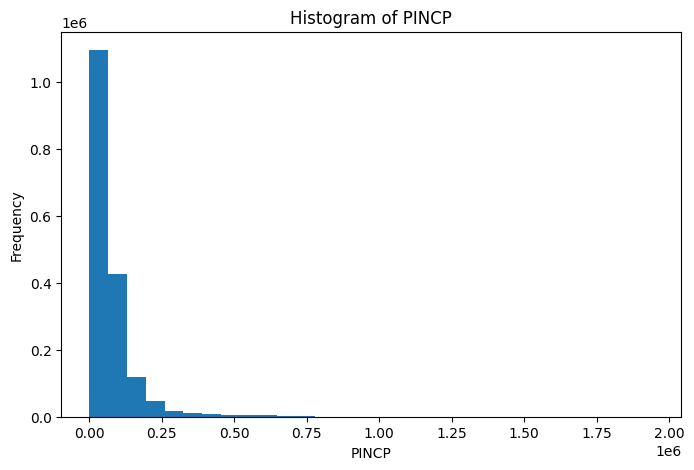

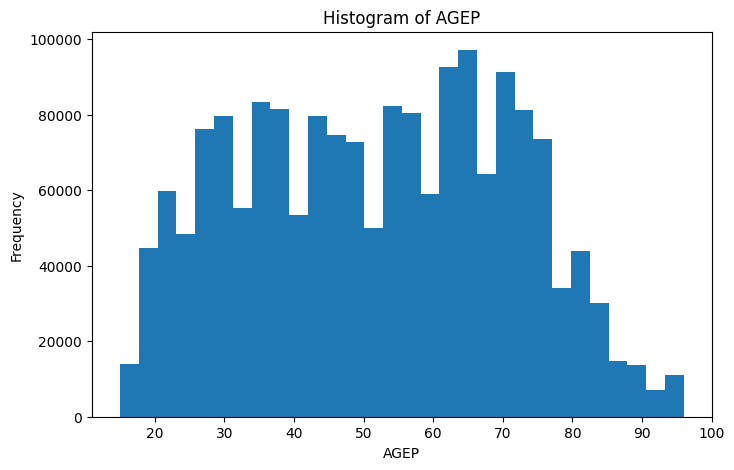

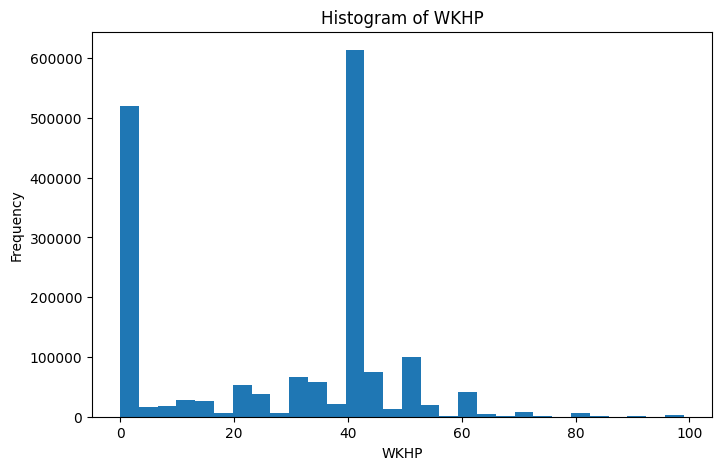

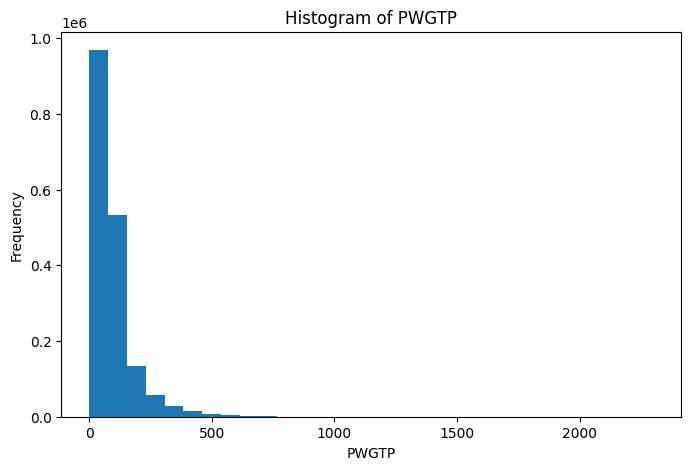

In [16]:
# Univariate Analysis using Histograms for response and continuous predictors

# Variable setup
response_var = 'PINCP'
continuous_predictors = ['AGEP', 'WKHP', 'PWGTP']
category_predictors = ['SEX', 'RAC1P', 'SCHL']

# loop through the response and each continuous predictor
for col in [response_var] + continuous_predictors:
  plt.figure(figsize=(8, 5)) # create a figure for the histogram
  plt.hist(income_df[col].dropna(), bins=30) # create a histogram and remove any missing values, use 30 bins for more bars & details
  plt.title(f'Histogram of {col}')
  plt.xlabel(col)
  plt.ylabel('Frequency') # use frequency as the y axis
  plt.show() # display

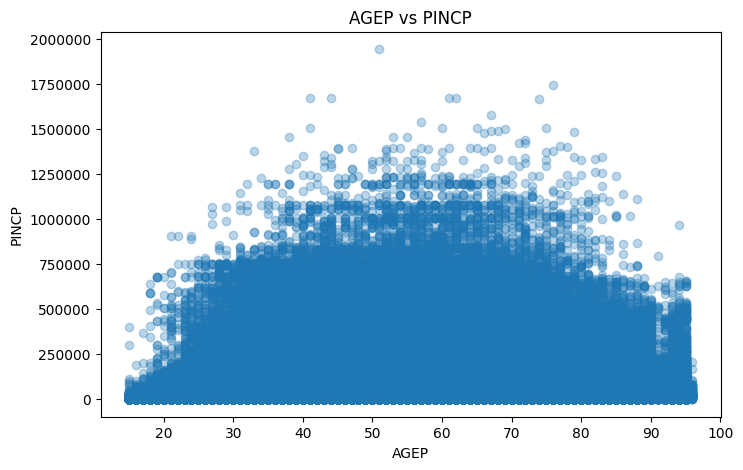

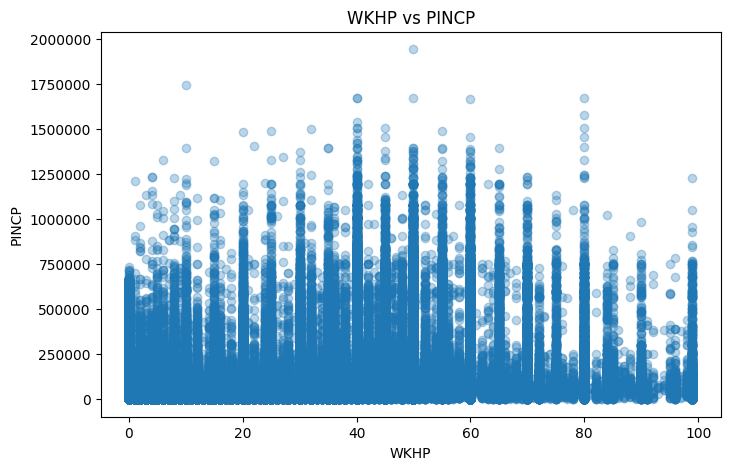

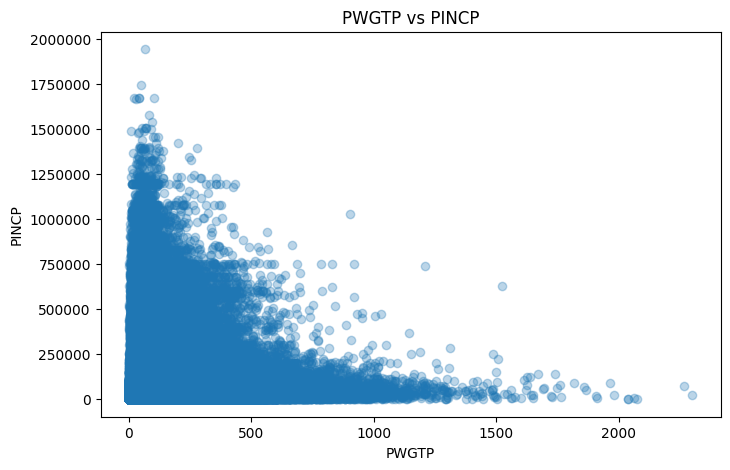

In [17]:
# Bivariate analysis using Scatterplots of predictors vs response

# Loop through each continuous predictor
for col in continuous_predictors:
    plt.figure(figsize=(8, 5)) # Create a new figure for the current scatterplot
    plt.scatter(income_df[col], income_df[response_var], alpha=0.3) # Plot predictor on x-axis and response on y-axis
    plt.title(f'{col} vs {response_var}') # Add a title
    plt.xlabel(col) # Label the x-axis with the predictor name
    plt.ylabel(response_var) # Label the y-axis with the response variable name
    plt.ticklabel_format(style='plain', axis='y')
    plt.show() # Display the graph

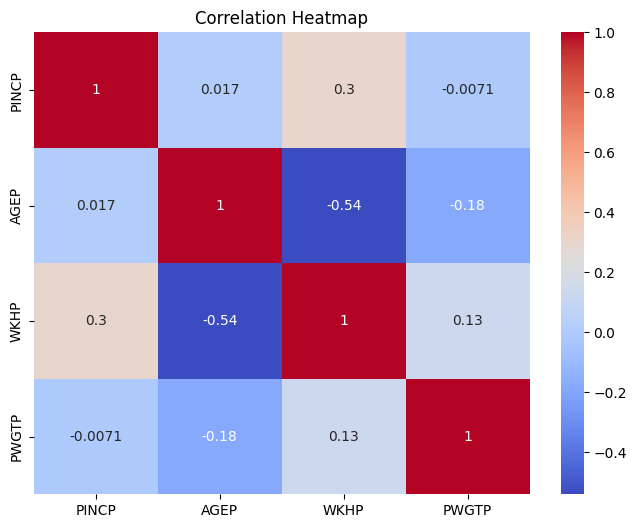

In [18]:
# Correlation Matrix using a heatmap for continuous variables

corr_matrix = income_df[[response_var] + continuous_predictors].corr() # Compute the correlation matrix for continuous variables
plt.figure(figsize=(8, 6)) # Create a figure for the heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm') # Draw the heatmap and show the correlation values
plt.title('Correlation Heatmap') # title it
plt.show() # Display the heatmap

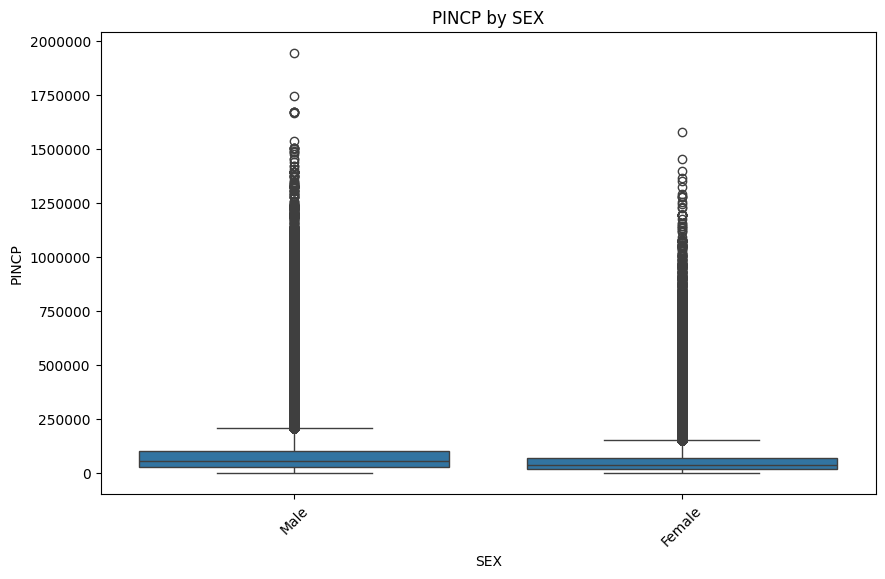

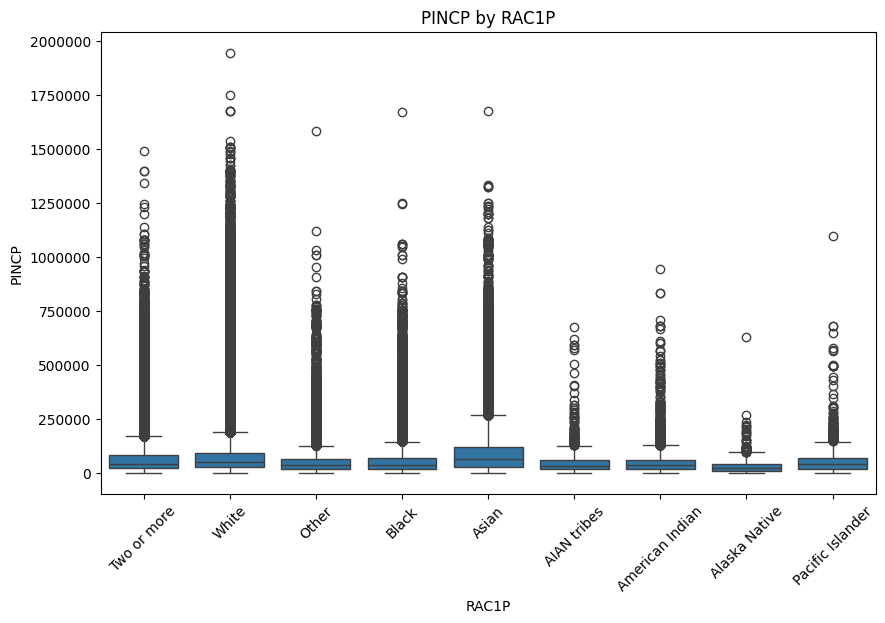

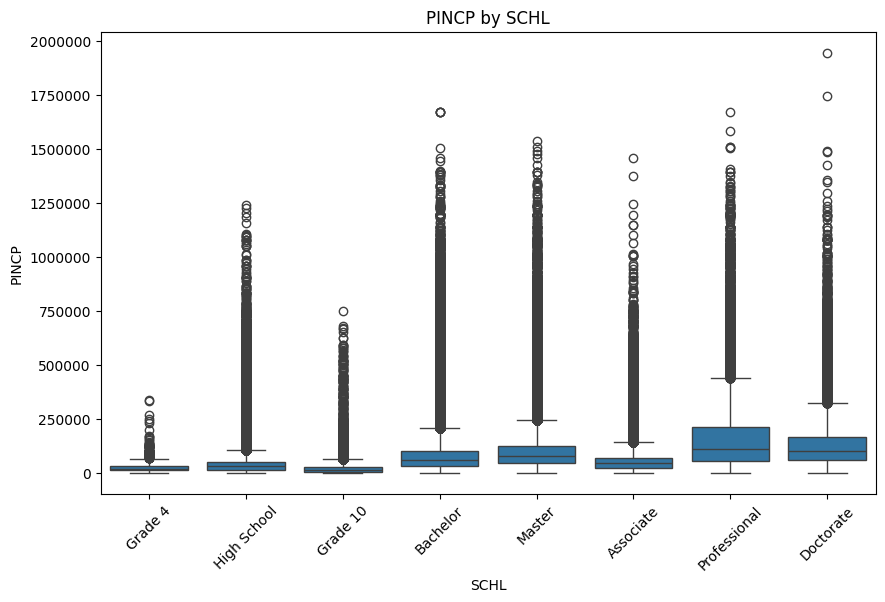

In [21]:
# Categorical variable analysis using Boxplot

# Loop through each categorical predictor
for col in category_predictors:
    plt.figure(figsize=(10, 6)) # Create a new figure for the current boxplot
    sns.boxplot(x=income_df[col], y=income_df[response_var]) # Draw a boxplot of the response grouped by the category
    plt.title(f'{response_var} by {col}') # Add a title to the graph
    plt.xlabel(col) # Label the x-axis with the categorical variable name
    plt.ylabel(response_var) # Label the y-axis with the response variable name
    plt.xticks(rotation=45) # Rotate category labels so they are easier to read
    plt.ticklabel_format(style='plain', axis='y')
    plt.show() # Display the graph

# Model Fit

In [27]:
income_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1749263 entries, 0 to 1749262
Data columns (total 7 columns):
 #   Column  Dtype 
---  ------  ----- 
 0   PWGTP   int64 
 1   SEX     object
 2   RAC1P   object
 3   SCHL    object
 4   PINCP   int64 
 5   AGEP    int64 
 6   WKHP    int64 
dtypes: int64(4), object(3)
memory usage: 93.4+ MB


In [28]:
income_df.head()

,PWGTP,SEX,RAC1P,SCHL,PINCP,AGEP,WKHP
0,78,Male,Two or more,Grade 4,70000,45,56
1,103,Male,White,High School,30000,25,80
2,42,Female,White,Grade 10,8700,50,0
3,54,Male,Two or more,High School,7000,19,6
4,54,Male,White,Bachelor,22800,57,0


In [29]:
income_df= income_df.assign(lny= (np.log(income_df.PINCP)))

In [30]:
income_lm = smf.ols(
    formula='lny ~ PWGTP + C(SEX) + C(RAC1P) + C(SCHL) + AGEP * WKHP + AGEP * C(SEX) + WKHP * C(SCHL)',
    data=income_df
).fit()

print(income_lm.summary())

                            OLS Regression Results                            
Dep. Variable:                    lny   R-squared:                       0.408
Model:                            OLS   Adj. R-squared:                  0.408
Method:                 Least Squares   F-statistic:                 4.301e+04
Date:                Thu, 30 Apr 2026   Prob (F-statistic):               0.00
Time:                        01:56:46   Log-Likelihood:            -2.3923e+06
No. Observations:             1749263   AIC:                         4.785e+06
Df Residuals:                 1749234   BIC:                         4.785e+06
Df Model:                          28                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept       

# Checking Regression Assumptions (Diagnostics)

In [31]:
# Pull fitted values and residuals from the final model.
fitted_values = income_lm.fittedvalues
residuals = income_lm.resid

# Number of observations used by the model.
n = int(income_lm.nobs)

# Number of estimated coefficients, including the intercept.
p = int(income_lm.df_model) + 1

plot_size = min(25000, n) # use at most 25000 rows so the diagnostic plots are not overcrowded & readable
diagnostic_plot_df = pd.DataFrame({"fitted_values": fitted_values, "residuals": residuals}) # create a small dataframe for plotting
diagnostic_plot_df = diagnostic_plot_df.sample(n=plot_size) # randomly samples rows for the diagnostic plots

print("Number of observations used in model:", n)
print("Number of model coefficients including intercept:", p)
print("Number of points used in diagnostic plots:", plot_size)

Number of observations used in model: 1749263
Number of model coefficients including intercept: 29
Number of points used in diagnostic plots: 25000


### Check linearity and equal variance (homoscedasticity)

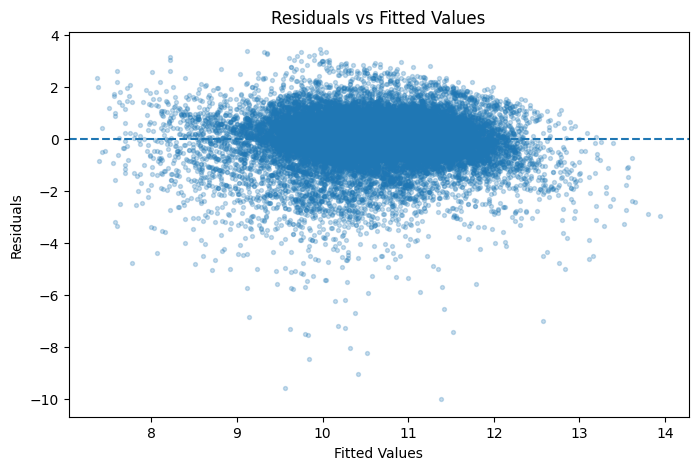

In [32]:
plt.figure(figsize=(8, 5))

# use alpha=0.25 and s=8 because it makes the plot easier to see
plt.scatter(
    diagnostic_plot_df["fitted_values"],
    diagnostic_plot_df["residuals"],
    alpha=0.25, # make points transparent
    s=8 # make points small
)
plt.axhline(0, linestyle="--") # adds a horizontal line at residual value 0
plt.title("Residuals vs Fitted Values")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.show()

### Independence check, Normality and Equal Variance Check

/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 25000.
  res = hypotest_fun_out(*samples, **kwds)


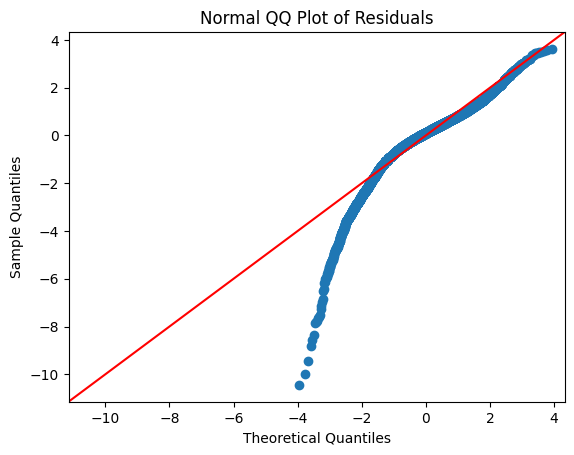

,Diagnostic,Value,Guidelines
0,Durbin Watson,1.885296e+00,Close to 2 is good for independence
1,Shapiro Wilk p value,5.231650e-76,p > 0.05 supports normal residuals
2,Breusch Pagan p value,0.000000e+00,p > 0.05 supports equal variance


In [33]:
# Independence check:

# Durbin Watson close to 2 means residuals are not strongly autocorrelated.
dw_stat = durbin_watson(residuals)

# Normality check using Shapiro Wilk Test
shapiro_sample = residuals.sample(n=plot_size)
shapiro_stat, shapiro_p = shapiro(diagnostic_plot_df["residuals"]) # calculate the Shapiro Wilk normality test

# QQ plot, looking for points mostly following a straight line
sm.qqplot(diagnostic_plot_df["residuals"], line="45", fit=True) # create the QQ plot using the sampled residuals
plt.title("Normal QQ Plot of Residuals")
plt.show()

# Equal variance check using Breusch Pagan: H0: constant variance / homoscedasticity, Ha: non constant variance / heteroscedasticity
bp_stat, bp_pvalue, bp_f_stat, bp_f_pvalue = het_breuschpagan(residuals, income_lm.model.exog) # calculate the Breusch Pagan test

# Put results into a clear table.
line_results = pd.DataFrame({
    'Diagnostic': [
        'Durbin Watson',
        'Shapiro Wilk p value',
        'Breusch Pagan p value'
    ],
    'Value': [
        dw_stat,
        shapiro_p,
        bp_pvalue
    ],
    'Guidelines': [
        'Close to 2 is good for independence',
        'p > 0.05 supports normal residuals',
        'p > 0.05 supports equal variance'
    ]
})

line_results


### check Multicollinearity using VIF

In [34]:
# Multicollinearity using VIF
# VIF < 5: normally okay, VIF 5-10: possible concern, VIF > 10: serious multicollinearity

X = income_lm.model.exog # predictor matrix from the fitted model
x_names = income_lm.model.exog_names # predictor names


MAX_ROWS = 50_000 # only do 50k because of RAM and runtime issue


if X.shape[0] > MAX_ROWS: # check if the dataset has more rows than the max allowed
    index = np.linspace(0, X.shape[0] - 1, MAX_ROWS, dtype=int) # select 50,000 evenly spaced row indexes
    X_vif = X[index, :] # create a smaller predictor matrix using the selected rows
else: # run if the dataset has 50,000 rows or fewer
    X_vif = X # use the full predictor matrix because it is small enough

# Compute VIF for each predictor
vif_list = [ # creates a list of dictionaries, where each dictionary stores one variable name and its VIF
    {"Variable": name, "VIF": variance_inflation_factor(X_vif, i)} # calculates the VIF for the predictor in column
    for i, name in enumerate(x_names) # loops through each predictor name and its column number
    if name != "Intercept" # skip the intercept
]

vif_df = pd.DataFrame(vif_list).sort_values("VIF", ascending=False) # turn the list into a dataframe and sorts from highest VIF to lowest VIF
vif_df.head(25)

,Variable,VIF
8,C(RAC1P)[T.White],217.648819
7,C(RAC1P)[T.Two or more],84.155041
4,C(RAC1P)[T.Black],76.922485
3,C(RAC1P)[T.Asian],69.368073
5,C(RAC1P)[T.Other],42.026560
19,WKHP,22.162732
27,AGEP:WKHP,10.924517
18,AGEP:C(SEX)[T.Male],9.445763
2,C(RAC1P)[T.American Indian],9.043678
0,C(SEX)[T.Male],8.745743


### Influential points: Checking for extreme outliers or high leverage points using Studentized residuals, Leverage values (hat matrix), and Cook's Distance.

In [35]:
# Influential Points Diagnostics

X = income_lm.model.exog # get the predictor matrix from the fitted model

residuals_all = np.asarray(income_lm.resid) # get all model residuals and converts them to a NumPy array

n = int(income_lm.nobs) # store the total number of observations used in the model
p = int(income_lm.df_model) + 1 # store the number of model coefficients, including the intercept
MAX_ROWS = 10000  # only checks 10,000 rows to reduce runtime & RAM usage (kept running out of RAM)

if n > MAX_ROWS: # check if the dataset is larger than the max number of rows
    idx = np.linspace(0, n - 1, MAX_ROWS, dtype=int) # selects 10,000 evenly spaced row indexes instead of random rows
else:
    idx = np.arange(n) # uses all rows if the dataset is already small enough

X_sample = X[idx, :] # keep only the selected rows from the predictor matrix
residuals_sample = residuals_all[idx] # keep only the selected residuals

mse = income_lm.mse_resid # get the models mean squared error
xtx_inv = np.asarray(income_lm.normalized_cov_params) # get the inverse of X'X (X transpose * X) from the fitted model

leverage = np.sum((X_sample @ xtx_inv) * X_sample, axis=1) # calculate leverage values for the selected rows
internal_studentized = residuals_sample / np.sqrt(mse * (1 - leverage)) # calculate internally studentized residuals
influence = income_lm.get_influence() # get influence measures
cooks_distance = influence.cooks_distance[0][idx] # get Cooks Distance

# creates a dataframe with the influence diagnostic values
influence_df = pd.DataFrame({
    "row_number": idx, # store the original row number from the dataset
    "studentized_residual": internal_studentized, # store studentized residuals for checking outliers
    "leverage": leverage, # store leverage values for checking unusual predictor values
    "cooks_distance": cooks_distance # store Cooks Distance for checking overall influence
})

studentized_cutoff = 3 # observations above 3 or below -3 may be possible outliers
leverage_cutoff = 2 * p / n # cutoff for high leverage
cooks_cutoff = 4 / n # cutoff for large Cooks Distance

influence_df["large_studentized_residual"] = abs(influence_df["studentized_residual"]) > studentized_cutoff # flags possible outliers
influence_df["high_leverage"] = influence_df["leverage"] > leverage_cutoff # flags high leverage points
influence_df["large_cooks_distance"] = influence_df["cooks_distance"] > cooks_cutoff # flags influential points

# creates a dataframe containing only flagged observations
flagged_points = influence_df[
    (influence_df["large_studentized_residual"]) | # keep rows with large studentized residuals
    (influence_df["high_leverage"]) | # keep rows with high leverage
    (influence_df["large_cooks_distance"]) # keep rows with large Cooks Distance
]

print("Rows checked:", len(influence_df)) # print how many rows were checked
print("Studentized residual cutoff:", studentized_cutoff) # print the studentized residual cutoff
print("Leverage cutoff:", leverage_cutoff) # print the leverage cutoff
print("Cook's Distance cutoff:", cooks_cutoff) # print the Cook's Distance cutoff
print("Number of flagged points:", len(flagged_points)) # print how many selected rows were flagged

flagged_points.head(25)

Rows checked: 10000
Studentized residual cutoff: 3
Leverage cutoff: 3.315682090114522e-05
Cook's Distance cutoff: 2.286677303527257e-06
Number of flagged points: 941


,row_number,studentized_residual,leverage,cooks_distance,large_studentized_residual,high_leverage,large_cooks_distance
0,0,0.154198,0.002060,1.692639e-06,False,True,False
3,524,-3.176106,0.000011,3.710355e-06,True,False,True
13,2274,0.143228,0.000499,3.533948e-07,False,True,False
14,2449,-3.386259,0.000016,6.358639e-06,True,False,True
16,2799,-2.367277,0.000024,4.701220e-06,False,False,True
45,7872,-3.508006,0.000015,6.526920e-06,True,False,True
54,9446,-4.410640,0.000006,4.072427e-06,True,False,True
55,9621,-4.814345,0.000010,7.956890e-06,True,False,True
64,11196,0.367642,0.000058,2.700047e-07,False,True,False
68,11896,-3.482755,0.000008,3.482630e-06,True,False,True


In [37]:
# show the 10 observations with the largest Cook's Distance
influence_df.sort_values("cooks_distance", ascending=False).head(10)

,row_number,studentized_residual,leverage,cooks_distance,large_studentized_residual,high_leverage,large_cooks_distance
6832,1195215,-1.887807,0.006777,0.000838,False,True,True
8169,1429115,-2.750605,0.001216,0.000317,False,True,True
430,75225,-8.250477,0.000074,0.000173,True,True,True
8825,1543878,-3.071647,0.000498,0.000162,True,True,True
1562,273262,1.924404,0.001249,0.000160,False,True,True
3089,540401,-2.404690,0.000772,0.000154,False,True,True
3577,625773,-1.973307,0.000765,0.000103,False,True,True
9252,1618579,-2.638755,0.000274,0.000066,False,True,True
209,36563,-5.326989,0.000060,0.000058,True,True,True
9225,1613855,-4.471215,0.000075,0.000052,True,True,True


# Remedial Measures for assumptions not met

In [38]:
print("Lets see what needs remedial measures")

if bp_pvalue == 0: # check to see if the breusch pagen p value had been rounded down to 0
    bp_display = "The p value is extremely small, so the equal variance assumption is not fully met"
else: # run if the p value is not rounded to 0
    bp_display = f"{bp_pvalue:.4e}" # display the p value in scientific notation

print("Breusch Pagan p value:", bp_display) # print the cleaned Breusch Pagan p value
print("Shapiro Wilk p value:", shapiro_p) # print the Shapiro Wilk p value
print("Highest VIF:", vif_df["VIF"].max()) # print the highest VIF value

 # check whether the equal variance assumption is violated
if bp_pvalue < 0.05:
    print("Equal variance is not fully met. The log transformation of income was used to help reduce unequal variance")
else: # run if the Breusch Pagan p value is not significant
    print("Equal variance appears reasonable based on the Breusch Pagan test")

 # check whether the residuals are not normally distributed
if shapiro_p < 0.05:
    print("Normality is not perfect. Since the dataset is very large, the QQ plot should also be used to judge normality")
else: # run if the Shapiro Wilk p value is not significant
    print("Normality appears reasonable based on the Shapiro Wilk test")

# check if multicollinearity may be serious
if vif_df["VIF"].max() > 10:
    print("Multicollinearity is high. The largest VIF values appear to come from categorical dummy variables and interaction terms."
    " As a remedial measure, the reference categories can be adjusted and AGEP/WKHP can be centered for interaction terms")
else:
    print("Multicollinearity does not appear to be a serious concern")

Lets see what needs remedial measures
Breusch Pagan p value: The p value is extremely small, so the equal variance assumption is not fully met
Shapiro Wilk p value: 5.2316500791378124e-76
Highest VIF: 217.64881935250705
Equal variance is not fully met. The log transformation of income was used to help reduce unequal variance
Normality is not perfect. Since the dataset is very large, the QQ plot should also be used to judge normality
Multicollinearity is high. The largest VIF values appear to come from categorical dummy variables and interaction terms. As a remedial measure, the reference categories can be adjusted and AGEP/WKHP can be centered for interaction terms


In [39]:
# REMEDIAL MEASURES FOR MULTICOLLINEARITY
income_df["AGEP_centered"] = income_df["AGEP"] - income_df["AGEP"].mean() # centers age by subtracting the mean age
income_df["WKHP_centered"] = income_df["WKHP"] - income_df["WKHP"].mean() # centers weekly work hours by subtracting the mean weekly work hours

# create the centered model
centered_income_lm = smf.ols(
    formula='lny ~ PWGTP + C(SEX) + C(RAC1P) + C(SCHL) + AGEP_centered * WKHP_centered + AGEP_centered * C(SEX) + WKHP_centered * C(SCHL)', # uses centered variables in interactions
    data=income_df
).fit()

print(centered_income_lm.summary()) # print the centered model summary

                            OLS Regression Results                            
Dep. Variable:                    lny   R-squared:                       0.408
Model:                            OLS   Adj. R-squared:                  0.408
Method:                 Least Squares   F-statistic:                 4.301e+04
Date:                Thu, 30 Apr 2026   Prob (F-statistic):               0.00
Time:                        02:23:50   Log-Likelihood:            -2.3923e+06
No. Observations:             1749263   AIC:                         4.785e+06
Df Residuals:                 1749234   BIC:                         4.785e+06
Df Model:                          28                                         
Covariance Type:            nonrobust                                         
                                            coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------

In [ ]:
# VIF Centered Model
X_centered = centered_income_lm.model.exog # get the predictor matrix from the centered model
x_centered_names = centered_income_lm.model.exog_names # get the predictor names from the centered model

if X_centered.shape[0] > MAX_ROWS: # check if the dataset has more than 50,000 rows
    idx = np.random.choice(X_centered.shape[0], size=MAX_ROWS, replace=False) # randomly samples 50,000 row indexes
    X_centered_vif = X_centered[idx, :] # keep only the sampled rows
else:
    X_centered_vif = X_centered # use the full predictor matrix if it is small enough

centered_vif_list = [ # create a list for centered model VIF values
    {"Variable": name, "VIF": variance_inflation_factor(X_centered_vif, i)} # calculate VIF for each predictor
    for i, name in enumerate(x_centered_names) # loop through predictor names and column indexes
    if name != "Intercept" # skip the intercept
]

centered_vif_df = pd.DataFrame(centered_vif_list).sort_values("VIF", ascending=False) # create and sorts the VIF table
centered_vif_df.head(25)

,Variable,VIF
8,C(RAC1P)[T.White],125.981911
7,C(RAC1P)[T.Two or more],49.565423
4,C(RAC1P)[T.Black],42.112214
3,C(RAC1P)[T.Asian],39.350855
5,C(RAC1P)[T.Other],27.703199
19,WKHP_centered,7.914596
2,C(RAC1P)[T.American Indian],6.026317
24,WKHP_centered:C(SCHL)[T.High School],3.579041
20,WKHP_centered:C(SCHL)[T.Bachelor],3.162386
17,AGEP_centered,2.617119


# Variable Selection Techniques

## Forward selection using AIC

In [ ]:
candidates= [
    "PWGTP",
    "C(SEX)",
    "C(RAC1P)",
    "C(SCHL)",
    "AGEP",
    "WKHP"
]

In [ ]:
forward_aic_income_lm, selected_vars=forward_selection_ic(income_df, 'lny', candidates)

print(selected_vars, end= " \n\n")

print(forward_aic_income_lm.summary())

['WKHP', 'C(SCHL)', 'AGEP', 'C(SEX)', 'C(RAC1P)', 'PWGTP'] 

                            OLS Regression Results                            
Dep. Variable:                    lny   R-squared:                       0.398
Model:                            OLS   Adj. R-squared:                  0.398
Method:                 Least Squares   F-statistic:                 6.085e+04
Date:                Tue, 28 Apr 2026   Prob (F-statistic):               0.00
Time:                        00:38:23   Log-Likelihood:            -2.4067e+06
No. Observations:             1749263   AIC:                         4.813e+06
Df Residuals:                 1749243   BIC:                         4.814e+06
Df Model:                          19                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------

In [ ]:
# Base model from forward selection
base_formula = 'lny ~ C(SCHL) + WKHP + AGEP + C(SEX) + C(RAC1P) + PWGTP'

base_model = smf.ols(base_formula, data=income_df).fit()
print("Base AIC:", base_model.aic)

# Interaction candidates
interactions = [
    "AGEP:WKHP",
    "AGEP:C(SEX)",
    "WKHP:C(SCHL)"
]

# Test interactions
results = []

for inter in interactions:
    formula = base_formula + " + " + inter
    model = smf.ols(formula, data=income_df).fit()
    results.append((inter, model.aic))

# Sort by AIC
results.sort(key=lambda x: x[1])

for r in results:
    print(r)

Base AIC: 4813408.219837654
('AGEP:WKHP', np.float64(4789268.5316374125))
('AGEP:C(SEX)', np.float64(4812065.30276666))
('WKHP:C(SCHL)', np.float64(4812071.992716287))


In [ ]:
final_forward_lm=smf.ols(formula= 'lny ~ C(SCHL) + WKHP + AGEP + C(SEX) + C(RAC1P) + PWGTP+ AGEP * WKHP + AGEP * C(SEX) + WKHP * C(SCHL)', data= income_df).fit()

print(final_forward_lm.summary())

                            OLS Regression Results                            
Dep. Variable:                    lny   R-squared:                       0.408
Model:                            OLS   Adj. R-squared:                  0.408
Method:                 Least Squares   F-statistic:                 4.301e+04
Date:                Tue, 28 Apr 2026   Prob (F-statistic):               0.00
Time:                        00:39:35   Log-Likelihood:            -2.3923e+06
No. Observations:             1749263   AIC:                         4.785e+06
Df Residuals:                 1749234   BIC:                         4.785e+06
Df Model:                          28                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept       

## Backward Elemination Using AIC

In [ ]:
backward_aic_income_lm, selected_vars=backward_elimination_ic(income_df, 'lny', candidates)

print(selected_vars, end= " \n\n")

print(backward_aic_income_lm.summary())

KeyboardInterrupt: 

In [ ]:
# Base model from backward elimination
base_formula = 'lny ~PWGTP +C(SEX)+(RAC1P)+C(SCHL)+AGEP+WKHP'

base_model = smf.ols(base_formula, data=income_df).fit()
print("Base AIC:", base_model.aic)

# Interaction candidates
interactions = [
    "AGEP:WKHP",
    "AGEP:C(SEX)",
    "WKHP:C(SCHL)"
]

# Test interactions
results = []

for inter in interactions:
    formula = base_formula + " + " + inter
    model = smf.ols(formula, data=income_df).fit()
    results.append((inter, model.aic))

# Sort by AIC
results.sort(key=lambda x: x[1])

for r in results:
    print(r)

In [ ]:
final_backward_lm= smf.ols(formula= 'lny ~PWGTP +C(SEX)+(RAC1P)+C(SCHL)+AGEP+WKHP + AGEP * WKHP + AGEP * C(SEX) + WKHP * C(SCHL)', data= income_df).fit()

print(final_backward_lm.summary())

## Compare Candidate Models

In [ ]:
# Put candidate models in a dictionary
models = {
    "final_backward_lm": final_backward_lm,
    "final_forward_lm": final_forward_lm,
    "income_lm": income_lm
}

full_model = income_lm

comparison_rows = []

for name, model in models.items():
    comparison_rows.append({
        "Model": name,
        "Adj_R2": model.rsquared_adj,
        "AIC": model.aic,
        "BIC": model.bic,
        "Mallows_Cp": get_mallows_cp(full_model, model),
        "Press_p":press_p(model)
    })

model_comparison = pd.DataFrame(comparison_rows)

# Sort by AIC, since lower AIC is usually preferred
model_comparison = model_comparison.sort_values(by="AIC")

print(model_comparison)

# Model Inference

Best model is the income_lm model

In [ ]:
print(income_lm.summary())

                            OLS Regression Results                            
Dep. Variable:                    lny   R-squared:                       0.408
Model:                            OLS   Adj. R-squared:                  0.408
Method:                 Least Squares   F-statistic:                 4.301e+04
Date:                Wed, 29 Apr 2026   Prob (F-statistic):               0.00
Time:                        20:09:37   Log-Likelihood:            -2.3923e+06
No. Observations:             1749263   AIC:                         4.785e+06
Df Residuals:                 1749234   BIC:                         4.785e+06
Df Model:                          28                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept       

## Hypothesis Testing- Type I Sequential

$ H_O $: Variable does not explain any additional variability

$ H_a $ : Varaible does  explain additional variability in the response

Significance Level:

$ \alpha $ level: 0.05

In [ ]:
print(anova_lm(income_lm, typ=1).round(7))

Conclusion: There is enough evidence at $\alpha$ = 0.05 to reject the null hypothesis, each variables adds a statistically significant amount of explanatory power to the model.

# Results

Joint CI

In [ ]:
# joint CI for mean Y using x-values

x_new = pd.DataFrame({
    "PWGTP": [80],
    "SEX": ["Male"],
    "RAC1P": ["Black"],
    "SCHL": ["Bachelor"],
    "AGEP": [35],
    "WKHP": [40]
})

income_pic= income_lm.get_prediction(x_new)

income_sum= income_pic.summary_frame(alpha= 0.05/1).round(2) # divide by number of intervals being created.

income_sum[['mean','mean_ci_lower','mean_ci_upper']]

print(np.exp(income_sum[['mean','mean_ci_lower','mean_ci_upper']]))

           mean  mean_ci_lower  mean_ci_upper
0  52052.078188   51534.151356    52575.21027


PI

In [ ]:
# PI for mean Y using x-values

x_new = pd.DataFrame({
    "PWGTP": [80],
    "SEX": ["Male"],
    "RAC1P": ["Black"],
    "SCHL": ["Bachelor"],
    "AGEP": [35],
    "WKHP": [40]
})

income_pic= income_lm.get_prediction(x_new)

pred_sum= income_pic.summary_frame(alpha= 0.05).round(2)

pred_sum[['obs_ci_lower', 'obs_ci_upper']]

print(np.exp(pred_sum[['obs_ci_lower', 'obs_ci_upper']]))

   obs_ci_lower   obs_ci_upper
0   8103.083928  334368.848683


In [ ]:
# Build summary table
income_summary_table = pd.DataFrame({
    "Variable": income_lm.params.index,
    "Coefficient (b)": income_lm.params.values,
    "Std. Error": income_lm.bse.values,
    "t-stat": income_lm.tvalues.values,
    "p-value": income_lm.pvalues.values
})

# Round for cleaner presentation
income_summary_table = income_summary_table.round(4)

(income_summary_table)

,Variable,Coefficient (b),Std. Error,t-stat,p-value
0,Intercept,7.7442,0.0219,353.7477,0.0000
1,C(SEX)[T.Male],0.0546,0.0042,12.8574,0.0000
2,C(RAC1P)[T.Alaska Native],-0.1555,0.0391,-3.9797,0.0001
3,C(RAC1P)[T.American Indian],0.0126,0.0227,0.5526,0.5805
4,C(RAC1P)[T.Asian],0.1488,0.0213,6.9814,0.0000
5,C(RAC1P)[T.Black],-0.0328,0.0213,-1.5423,0.1230
6,C(RAC1P)[T.Other],0.0093,0.0214,0.4337,0.6645
7,C(RAC1P)[T.Pacific Islander],0.0656,0.0290,2.2671,0.0234
8,C(RAC1P)[T.Two or more],0.0652,0.0213,3.0654,0.0022
9,C(RAC1P)[T.White],0.1695,0.0211,8.0123,0.0000


In [ ]:
# Define quantitative variables
quant_vars = ["PWGTP", "AGEP", "WKHP", "PINCP"]

# Create summary table
quant_summary = pd.DataFrame({
    "Mean": income_df[quant_vars].mean(),
    "Median": income_df[quant_vars].median(),
    "Std Dev": income_df[quant_vars].std(),
    "Min": income_df[quant_vars].min(),
    "Max": income_df[quant_vars].max()
})

# Add range
quant_summary["Range"] = quant_summary["Max"] - quant_summary["Min"]

# Drop min/max if you only want range
quant_summary = quant_summary.drop(columns=["Min", "Max"])

(quant_summary.round(2))

,Mean,Median,Std Dev,Range
PWGTP,95.17,71.0,85.99,2299
AGEP,51.89,53.0,19.05,81
WKHP,27.06,40.0,20.40,99
PINCP,72032.47,48000.0,91695.44,1944999


In [ ]:
# Define categorical variables
cat_vars = ["SEX", "RAC1P", "SCHL"]

# Loop through and print frequency tables
for var in cat_vars:
    print(f"\nFrequency table for {var}:")

    freq_table = income_df[var].value_counts(dropna=False)
    percent_table = income_df[var].value_counts(normalize=True, dropna=False) * 100

    summary = pd.DataFrame({
        "Count": freq_table,
        "Percent (%)": percent_table
    })

    print(summary.round(2))


Frequency table for SEX:
         Count  Percent (%)
SEX                        
Female  897809        51.32
Male    851454        48.68

Frequency table for RAC1P:
                    Count  Percent (%)
RAC1P                                 
White             1264557        72.29
Two or more        151083         8.64
Black              130136         7.44
Asian              117523         6.72
Other               67802         3.88
American Indian     13003         0.74
Pacific Islander     2302         0.13
AIAN tribes          2022         0.12
Alaska Native         835         0.05

Frequency table for SCHL:
               Count  Percent (%)
SCHL                             
High School   576051        32.93
Bachelor      544217        31.11
Master        261334        14.94
Associate     221542        12.66
Professional   60416         3.45
Doctorate      46096         2.64
Grade 10       37324         2.13
Grade 4         2283         0.13
